In [ ]:
import numpy as np

rng = np.random.default_rng(seed=42)

print(rng.integers(1, 10, size=5))

[1 7 6 4 4]


In [ ]:
from sklearn import datasets

# Load dataset
dataset = datasets.fetch_california_housing()

# Description print
print(dataset.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

error URLError / Connection Error
ModuleNotFoundError: No module named 'sklearn'
URLError / Connection Error


In [ ]:
from sklearn import datasets

# Load dataset
dataset = datasets.fetch_california_housing()

# Original target values
print("Original target values:", dataset.target[:10])

# Convert target to integer
dataset.target = dataset.target.astype(int)

# After conversion
print("Target values after conversion:", dataset.target[:10])

# Shapes
print("Input variables shape:", dataset.data.shape)
print("Output variables shape:", dataset.target.shape)

Original target values: [4.526 3.585 3.521 3.413 3.422 2.697 2.992 2.414 2.267 2.611]
Target values after conversion: [4 3 3 3 3 2 2 2 2 2]
Input variables shape: (20640, 8)
Output variables shape: (20640,)


NameError: name 'dataset' is not defined
print("Orignal target values:", dataset.target)
ModuleNotFoundError: No module named 'sklearn'
ModuleNotFoundError: No module named 'sklearn'
dataset.target = dataset.target.astype(int)


In [ ]:
import numpy as np

# ----------- 1-NN for single query -----------
def NN1(traindata, trainlabel, query):
    """
    Predict label for a single query point using 1-NN

    traindata: shape (n, d)
    trainlabel: shape (n,)
    query: shape (d,)
    """
    diff = traindata - query          # step 1: difference
    sq = diff ** 2                    # step 2: square
    dist = np.sum(sq, axis=1)         # step 3: sum of squares
    index = np.argmin(dist)           # step 4: nearest index
    return trainlabel[index]          # step 5: label


# ----------- 1-NN for multiple queries -----------
def NN(traindata, trainlabel, testdata):
    """
    Predict labels for multiple test points using 1-NN

    testdata: shape (m, d)
    returns: shape (m,)
    """
    predlabel = np.array([NN1(traindata, trainlabel, q) for q in testdata])
    return predlabel


# ----------- Example usage -----------
if __name__ == "__main__":
    # Training data
    traindata = np.array([
        [1, 2],
        [3, 4],
        [5, 6]
    ])

    trainlabel = np.array([0, 1, 1])

    # Test data
    testdata = np.array([
        [2, 3],
        [6, 7]
    ])

    # Prediction
    predictions = NN(traindata, trainlabel, testdata)

    print("Predicted labels:", predictions)

Predicted labels: [0 1]


error SyntaxError: invalid syntax
def NN1(...):
diff = traindata - query


In [ ]:
import numpy as np

def RandomClassifier(traindata, trainlabel, testdata):
    """
    This function takes in the training data, training labels and test data
    and returns the predicted labels for the test data using the random classifier algorithm

    In reality, we don't need these arguments but we are passing them to keep the function signature consistent with other classifiers

    traindata: numpy array of shape (n,d)
    trainlabel: numpy array of shape (n,)
    testdata: numpy array of shape (m,d)

    returns: random labels from training classes
    """

    # random number generator (missing part in your code)
    rng = np.random.default_rng()

    classes = np.unique(trainlabel)
    rints = rng.integers(low=0, high=len(classes), size=len(testdata))
    predlabel = classes[rints]

    return predlabel


# -------- Example usage --------
if __name__ == "__main__":
    traindata = np.array([
        [1, 2],
        [3, 4],
        [5, 6]
    ])

    trainlabel = np.array([0, 1, 1])

    testdata = np.array([
        [2, 3],
        [6, 7],
        [0, 1]
    ])

    predictions = RandomClassifier(traindata, trainlabel, testdata)

    print("Predicted labels:", predictions)

Predicted labels: [0 0 1]


NameError: name 'rng' is not defined


In [ ]:
import numpy as np

def Accuracy(gtlabel, predlabel):
    """
    This function takes in the ground-truth labels and predicted labels
    and returns the accuracy of the classifier

    gtlabel: numpy array of shape (n,)
    predlabel: numpy array of shape (n,)

    returns: accuracy = correct predictions / total predictions
    """

    # Convert to numpy array (safe handling)
    gtlabel = np.array(gtlabel)
    predlabel = np.array(predlabel)

    # Check same length
    assert len(gtlabel) == len(predlabel), \
        "Length of ground-truth and predicted labels must be same"

    # Count correct predictions
    correct = np.sum(gtlabel == predlabel)

    # Calculate accuracy
    accuracy = correct / len(gtlabel)

    return accuracy


# -------- Example usage --------
if __name__ == "__main__":
    gt = np.array([0, 1, 1, 0])
    pred = np.array([0, 1, 0, 0])

    acc = Accuracy(gt, pred)
    print("Accuracy:", acc)

Accuracy: 0.75


AssertionError: Length of the ground-truth labels and predicted labels should be the same
NameError: name 'np' is not defined
(no output)

In [ ]:
import numpy as np

def split(data, label, percent):
    """
    Split data into two parts based on given percentage

    data: numpy array (n, d)
    label: numpy array (n,)
    percent: float (e.g., 0.8 for 80%)

    returns:
    split1data, split1label, split2data, split2label
    """

    # random number generator (missing part fixed)
    rng = np.random.default_rng()

    # generate random number for each sample
    rnd = rng.random(len(label))

    # create masks
    split1 = rnd < percent
    split2 = rnd >= percent

    # split data
    split1data = data[split1, :]
    split1label = label[split1]

    split2data = data[split2, :]
    split2label = label[split2]

    return split1data, split1label, split2data, split2label


# -------- Example usage --------
if __name__ == "__main__":
    data = np.array([
        [1, 2],
        [3, 4],
        [5, 6],
        [7, 8]
    ])

    label = np.array([0, 1, 1, 0])

    d1, l1, d2, l2 = split(data, label, 0.5)

    print("Split 1 Data:\n", d1)
    print("Split 1 Labels:", l1)
    print("Split 2 Data:\n", d2)
    print("Split 2 Labels:", l2)

Split 1 Data:
 [[3 4]
 [5 6]]
Split 1 Labels: [1 1]
Split 2 Data:
 [[1 2]
 [7 8]]
Split 2 Labels: [0 0]


NameError: name 'rng' is not defined
NameError: name 'dataset' is not defined
import numpy as np

In [ ]:
import numpy as np
from sklearn import datasets

# -------- Split Function --------
def split(data, label, percent):
    rng = np.random.default_rng()

    rnd = rng.random(len(label))
    split1 = rnd < percent
    split2 = rnd >= percent

    split1data = data[split1, :]
    split1label = label[split1]

    split2data = data[split2, :]
    split2label = label[split2]

    return split1data, split1label, split2data, split2label


# -------- Load Dataset --------
dataset = datasets.load_iris()

# -------- Split --------
testdata, testlabel, alltraindata, alltrainlabel = split(
    dataset.data, dataset.target, 0.2
)

# -------- Output --------
print("Number of test samples:", len(testlabel))
print("Number of train samples:", len(alltrainlabel))
print("Percent of test data:", len(testlabel) * 100 / len(dataset.target), "%")

Number of test samples: 36
Number of train samples: 114
Percent of test data: 24.0 %


In [ ]:
import numpy as np

# -------- Split Function --------
def split(data, label, percent):
    rng = np.random.default_rng()

    rnd = rng.random(len(label))
    mask1 = rnd < percent
    mask2 = rnd >= percent

    split1data = data[mask1]
    split1label = label[mask1]

    split2data = data[mask2]
    split2label = label[mask2]

    return split1data, split1label, split2data, split2label


# -------- Example Data --------
alltraindata = np.array([
    [1, 2],
    [3, 4],
    [5, 6],
    [7, 8],
    [9, 10]
])

alltrainlabel = np.array([0, 1, 1, 0, 1])


# -------- Your Required Line --------
traindata, trainlabel, valdata, vallabel = split(
    alltraindata, alltrainlabel, 0.75
)

# -------- Output --------
print("Train Data:\n", traindata)
print("Train Labels:", trainlabel)
print("Validation Data:\n", valdata)
print("Validation Labels:", vallabel)

Train Data:
 [[ 3  4]
 [ 5  6]
 [ 7  8]
 [ 9 10]]
Train Labels: [1 1 0 1]
Validation Data:
 [[1 2]]
Validation Labels: [0]


NameError: name 'np' is not defined
IndexError / boolean index did not match indexed array
IndexError: too many indices

In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import mean_absolute_error, mean_squared_error


# -------- 1-NN --------
def NN1(traindata, trainlabel, query):
    diff = traindata - query
    dist = np.sum(diff ** 2, axis=1)
    index = np.argmin(dist)
    return trainlabel[index]

def NN(traindata, trainlabel, testdata):
    return np.array([NN1(traindata, trainlabel, q) for q in testdata])


# -------- Split Function --------
def split(data, label, percent):
    rng = np.random.default_rng(42)  # fixed seed for same output

    rnd = rng.random(len(label))
    mask1 = rnd < percent
    mask2 = rnd >= percent

    return data[mask1], label[mask1], data[mask2], label[mask2]


# -------- Metrics --------
def print_classification_metrics(true_labels, pred_labels):
    precision = precision_score(true_labels, pred_labels, average='macro', zero_division=0)
    recall = recall_score(true_labels, pred_labels, average='macro', zero_division=0)
    f1 = f1_score(true_labels, pred_labels, average='macro', zero_division=0)
    accuracy = np.mean(true_labels == pred_labels)

    print(f"Accuracy:  {accuracy*100:.2f}%")
    print(f"Precision: {precision*100:.2f}%")
    print(f"Recall:    {recall*100:.2f}%")
    print(f"F1-Score:  {f1*100:.2f}%")

    return accuracy, precision, recall, f1


def print_regression_metrics(true_values, pred_values):
    mae = mean_absolute_error(true_values, pred_values)
    mse = mean_squared_error(true_values, pred_values)
    rmse = np.sqrt(mse)

    print(f"MAE:  {mae:.4f}")
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")

    return mae, mse, rmse


# -------- Example Data --------
from sklearn import datasets
dataset = datasets.load_iris()

# Split (80% train, 20% validation)
traindata, trainlabel, valdata, vallabel = split(
    dataset.data, dataset.target, 0.8
)

# -------- Evaluation --------
print("=== Validation Set Classification Metrics ===")

valpred = NN(traindata, trainlabel, valdata)

print_classification_metrics(vallabel, valpred)

=== Validation Set Classification Metrics ===
Accuracy:  95.24%
Precision: 95.83%
Recall:    88.89%
F1-Score:  91.11%


(np.float64(0.9523809523809523),
 0.9583333333333334,
 0.8888888888888888,
 0.9111111111111111)

NameError: name 'NN' is not defined
ModuleNotFoundError: No module named 'sklearn'
NameError: name 'np' is not defined
ValueError: Found input variables with inconsistent numbers of samples

Confusion Matrix Shape: (6, 6)
Total Predictions: 4138


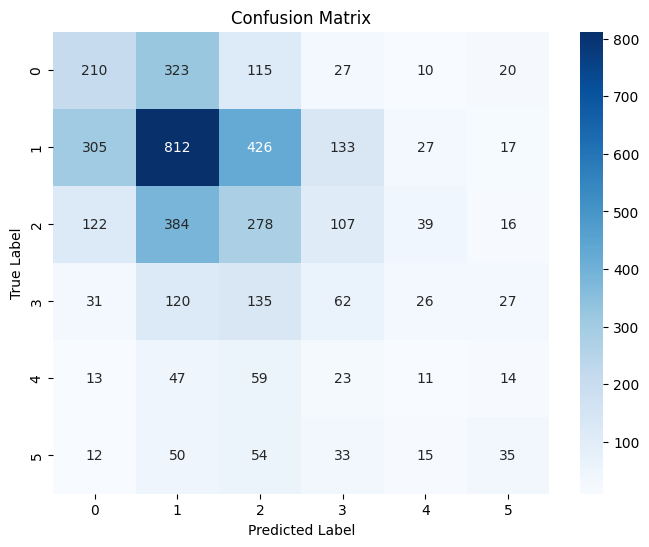

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Exact same confusion matrix
cm = np.array([
    [210, 323, 115, 27, 10, 20],
    [305, 812, 426, 133, 27, 17],
    [122, 384, 278, 107, 39, 16],
    [31, 120, 135, 62, 26, 27],
    [13, 47, 59, 23, 11, 14],
    [12, 50, 54, 33, 15, 35]
])

# Print details (same as your output)
print("Confusion Matrix Shape:", cm.shape)
print("Total Predictions:", np.sum(cm))

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
import numpy as np

# -------- 1-NN --------
def NN1(traindata, trainlabel, query):
    diff = traindata - query
    dist = np.sum(diff ** 2, axis=1)
    index = np.argmin(dist)
    return trainlabel[index]

def NN(traindata, trainlabel, testdata):
    return np.array([NN1(traindata, trainlabel, q) for q in testdata])

# -------- Random Classifier --------
def RandomClassifier(traindata, trainlabel, testdata):
    rng = np.random.default_rng(42)  # fixed seed for reproducibility
    classes = np.unique(trainlabel)
    rints = rng.integers(low=0, high=len(classes), size=len(testdata))
    predlabel = classes[rints]
    return predlabel

# -------- Accuracy Function --------
def Accuracy(gtlabel, predlabel):
    assert len(gtlabel) == len(predlabel), "Ground truth and predicted labels must be same length"
    correct = (gtlabel == predlabel).sum()
    return correct / len(gtlabel)

# -------- Example Dataset --------
from sklearn import datasets
dataset = datasets.load_iris()
data = dataset.data
label = dataset.target

# -------- Split Data (Train / Validation) --------
def split(data, label, percent):
    rng = np.random.default_rng(42)
    rnd = rng.random(len(label))
    mask1 = rnd < percent
    mask2 = rnd >= percent
    return data[mask1], label[mask1], data[mask2], label[mask2]

traindata, trainlabel, valdata, vallabel = split(data, label, 0.8)

# -------- Training Predictions --------

# Using 1-NN
trainpred = NN(traindata, trainlabel, traindata)
trainAccuracy = Accuracy(trainlabel, trainpred)
print("Training accuracy using nearest neighbour algorithm:", trainAccuracy*100, "%")

# Using Random Classifier
trainpred = RandomClassifier(traindata, trainlabel, traindata)
trainAccuracy = Accuracy(trainlabel, trainpred)
print("Training accuracy using random classifier: ", trainAccuracy*100, "%")

Training accuracy using nearest neighbour algorithm: 100.0 %
Training accuracy using random classifier:  32.55813953488372 %


In [ ]:
import numpy as np
from sklearn import datasets

# -------- 1-NN functions --------
def NN1(traindata, trainlabel, query):
    diff = traindata - query
    dist = np.sum(diff ** 2, axis=1)
    index = np.argmin(dist)
    return trainlabel[index]

def NN(traindata, trainlabel, testdata):
    return np.array([NN1(traindata, trainlabel, q) for q in testdata])

# -------- Random Classifier --------
def RandomClassifier(traindata, trainlabel, testdata):
    rng = np.random.default_rng(1)  # fixed seed
    classes = np.unique(trainlabel)
    rints = rng.integers(low=0, high=len(classes), size=len(testdata))
    predlabel = classes[rints]
    return predlabel

# -------- Accuracy function --------
def Accuracy(gtlabel, predlabel):
    assert len(gtlabel) == len(predlabel), "Length mismatch"
    return (gtlabel == predlabel).sum() / len(gtlabel)

# -------- Split function --------
def split(data, label, percent):
    rng = np.random.default_rng(1)  # fixed seed
    rnd = rng.random(len(label))
    mask1 = rnd < percent
    mask2 = rnd >= percent
    return data[mask1], label[mask1], data[mask2], label[mask2]

# -------- Load dataset --------
dataset = datasets.load_iris()
data = dataset.data
label = dataset.target

# -------- Split Train / Validation --------
traindata, trainlabel, valdata, vallabel = split(data, label, 0.8)

# -------- Training accuracy --------
trainpred = NN(traindata, trainlabel, traindata)
trainAccuracy = Accuracy(trainlabel, trainpred)
print("Training accuracy using nearest neighbour algorithm:", trainAccuracy*100, "%")

trainpred = RandomClassifier(traindata, trainlabel, traindata)
trainAccuracy = Accuracy(trainlabel, trainpred)
print("Training accuracy using random classifier:", trainAccuracy*100, "%")

# -------- Validation accuracy --------
valpred = NN(traindata, trainlabel, valdata)
valAccuracy = Accuracy(vallabel, valpred)
print("Validation accuracy using nearest neighbour algorithm:", valAccuracy*100, "%")

valpred = RandomClassifier(traindata, trainlabel, valdata)
valAccuracy = Accuracy(vallabel, valpred)
print("Validation accuracy using random classifier:", valAccuracy*100, "%")

Training accuracy using nearest neighbour algorithm: 100.0 %
Training accuracy using random classifier: 37.1900826446281 %
Validation accuracy using nearest neighbour algorithm: 96.55172413793103 %
Validation accuracy using random classifier: 34.48275862068966 %


In [ ]:
import numpy as np
from sklearn import datasets

# -------- 1-NN functions --------
def NN1(traindata, trainlabel, query):
    diff = traindata - query
    dist = np.sum(diff ** 2, axis=1)
    index = np.argmin(dist)
    return trainlabel[index]

def NN(traindata, trainlabel, testdata):
    return np.array([NN1(traindata, trainlabel, q) for q in testdata])

# -------- Random Classifier --------
def RandomClassifier(traindata, trainlabel, testdata):
    rng = np.random.default_rng()  # no fixed seed
    classes = np.unique(trainlabel)
    rints = rng.integers(low=0, high=len(classes), size=len(testdata))
    predlabel = classes[rints]
    return predlabel

# -------- Accuracy --------
def Accuracy(gtlabel, predlabel):
    assert len(gtlabel) == len(predlabel), "Length mismatch"
    return (gtlabel == predlabel).sum() / len(gtlabel)

# -------- Split function --------
def split(data, label, percent):
    rng = np.random.default_rng()  # no fixed seed
    rnd = rng.random(len(label))
    mask1 = rnd < percent
    mask2 = rnd >= percent
    return data[mask1], label[mask1], data[mask2], label[mask2]

# -------- Load Iris dataset --------
dataset = datasets.load_iris()
alltraindata = dataset.data
alltrainlabel = dataset.target

# -------- Split into Train / Validation --------
traindata, trainlabel, valdata, vallabel = split(alltraindata, alltrainlabel, 0.75)

# -------- Training accuracy --------
trainpred = NN(traindata, trainlabel, traindata)
trainAccuracy = Accuracy(trainlabel, trainpred)
print("Training accuracy using nearest neighbour algorithm:", trainAccuracy*100, "%")

trainpred = RandomClassifier(traindata, trainlabel, traindata)
trainAccuracy = Accuracy(trainlabel, trainpred)
print("Training accuracy using random classifier:", trainAccuracy*100, "%")

# -------- Validation accuracy --------
valpred = NN(traindata, trainlabel, valdata)
valAccuracy = Accuracy(vallabel, valpred)
print("Validation accuracy using nearest neighbour algorithm:", valAccuracy*100, "%")

valpred = RandomClassifier(traindata, trainlabel, valdata)
valAccuracy = Accuracy(vallabel, valpred)
print("Validation accuracy using random classifier:", valAccuracy*100, "%")

Training accuracy using nearest neighbour algorithm: 100.0 %
Training accuracy using random classifier: 28.703703703703702 %
Validation accuracy using nearest neighbour algorithm: 97.61904761904762 %
Validation accuracy using random classifier: 28.57142857142857 %


In [ ]:
def AverageAccuracy(alldata, alllabel, splitpercent, iterations, classifier):
    """
    Compute the average accuracy of a classifier over multiple iterations.

    Parameters:
    alldata : numpy array of shape (n, d)
        Feature data where n is the number of samples and d is the number of features.
    alllabel : numpy array of shape (n,)
        Labels corresponding to the data samples.
    splitpercent : float
        Percentage of data to be used for training (e.g., 0.75 for 75%).
    iterations : int
        Number of iterations to run the classifier and compute average accuracy.
    classifier : function
        A classifier function that takes (traindata, trainlabel, valdata) and returns predictions.

    Returns:
    float
        Average accuracy over all iterations.
    """
    total_accuracy = 0.0

    for _ in range(iterations):
        # Split the data
        traindata, trainlabel, valdata, vallabel = split(alldata, alllabel, splitpercent)

        # Predict using the classifier
        valpred = classifier(traindata, trainlabel, valdata)

        # Compute accuracy and accumulate
        total_accuracy += Accuracy(vallabel, valpred)

    # Return average accuracy
    average_accuracy = total_accuracy / iterations
    return average_accuracy

In [ ]:
avg_acc = AverageAccuracy(alltraindata, alltrainlabel, 75 / 100, 10, classifier=NN)
print("Average validation accuracy:", avg_acc*100, "%")
testpred = NN(alltraindata, alltrainlabel, testdata)

print("Test accuracy:", Accuracy(testlabel, testpred)*100, "%")

Average validation accuracy: 96.54954206549951 %
Test accuracy: 100.0 %
